# Following two latent traits over time

This tutorial extends the [static example](tutorial_static.ipynb) to repeated binary responses at irregular times. Each respondent has two latent trajectories, modeled with **exact Gaussian processes (GPs)** using a `tinygp` kernel. We fit the model with **stochastic variational inference (SVI)**, inspect the items, and reconstruct trajectories between observations.

Run the notebook from top to bottom in an environment with `dynamirt`, `tinygp`, ArviZ 1.x, and Jupyter. Exact GPs work well for this small example with short individual time series; their cost grows cubically with the number of time points per respondent.

In [1]:
import jax

# Dense GP covariance matrices benefit from double precision.
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
import tinygp
import xarray as xr
from numpyro.infer import Predictive
from tinygp import kernels

from dynamirt import Confirmatory, ExactGP, Param, dynamirt, fit_svi, q_matrix
from dynamirt.diagnostics import item_curves, plot_item_curves, plot_loadings, plot_trajectories

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

/home/jrc002/anaconda3/envs/jax_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jrc002/anaconda3/envs/jax_env/lib/python3.12/site-packages/jax/experimental/sparse/linalg.py:34: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  import scipy.sparse


## 1. Simulate irregular observations

We simulate 100 respondents, each observed 8–11 times on a scaled time axis from −1 to 1. The first five items measure `latent_0`; the other five measure `latent_1`. As before, `q_matrix` encodes which loadings are allowed to be nonzero.

Each row of `responses` is now a **respondent–time observation**. The matching entries in `covariates` identify the respondent and time; rows need not form a rectangular panel.

In [2]:
n_respondents, n_items, n_latent = 100, 10, 2
n_dense = 100
item_names = [f"item_{j}" for j in range(n_items)]
latent_names = [f"latent_{j}" for j in range(n_latent)]
Q = q_matrix([np.arange(5), np.arange(5, 10)], items=n_items)

dense_time = np.linspace(-1, 1, n_dense)
example_respondents = [0, 3, 7]

The squared-exponential kernel generates smooth, independent trajectories with marginal variance one and length scale 0.5. We sample the irregular observations and dense reference grid **jointly**, so both belong to the same GP realization. A conditional mean alone would smooth away the remaining uncertainty and would not be a sampled “true” path.

The response logit is `theta @ a_true.T + d_true`: larger additive intercepts make a positive response more likely. The simulation code is marked as collapsible, as in the static tutorial.

In [3]:
rng = np.random.default_rng(0)
key = jax.random.PRNGKey(0)
true_length_scale = 0.5
simulation_kernel = kernels.ExpSquared(scale=true_length_scale)

respondent_parts, time_parts, theta_parts = [], [], []
dense_trajectories = np.empty((n_respondents, n_dense, n_latent))

for respondent in range(n_respondents):
    n_times = rng.integers(8, 12)
    times = np.sort(rng.uniform(-1, 1, n_times))
    joint_time = jnp.asarray(np.concatenate([times, dense_time]))
    gp = tinygp.GaussianProcess(simulation_kernel, joint_time, diag=1e-6)
    key, draw_key = jax.random.split(key)
    joint_draw = np.asarray(gp.sample(draw_key, shape=(n_latent,))).T

    respondent_parts.append(np.full(n_times, respondent))
    time_parts.append(times)
    theta_parts.append(joint_draw[:n_times])
    dense_trajectories[respondent] = joint_draw[n_times:]

covariates = {
    "respondent_idx": np.concatenate(respondent_parts),
    "time": np.concatenate(time_parts),
}
theta_true = np.concatenate(theta_parts)
n_obs = len(theta_true)

a_true = np.where(Q, rng.uniform(0.8, 2.0, (n_items, n_latent)), 0.0)
d_true = rng.normal(0, 0.5, n_items)
logits = theta_true @ a_true.T + d_true
probabilities = 1 / (1 + np.exp(-logits))
responses = (rng.random((n_obs, n_items)) < probabilities).astype(float)

The left panels show the true trajectories, with dots at observation times. On the right, each column of squares is one visit and each row is an item; the spacing preserves the actual observation times. Binary responses are noisy even when the underlying traits change smoothly.

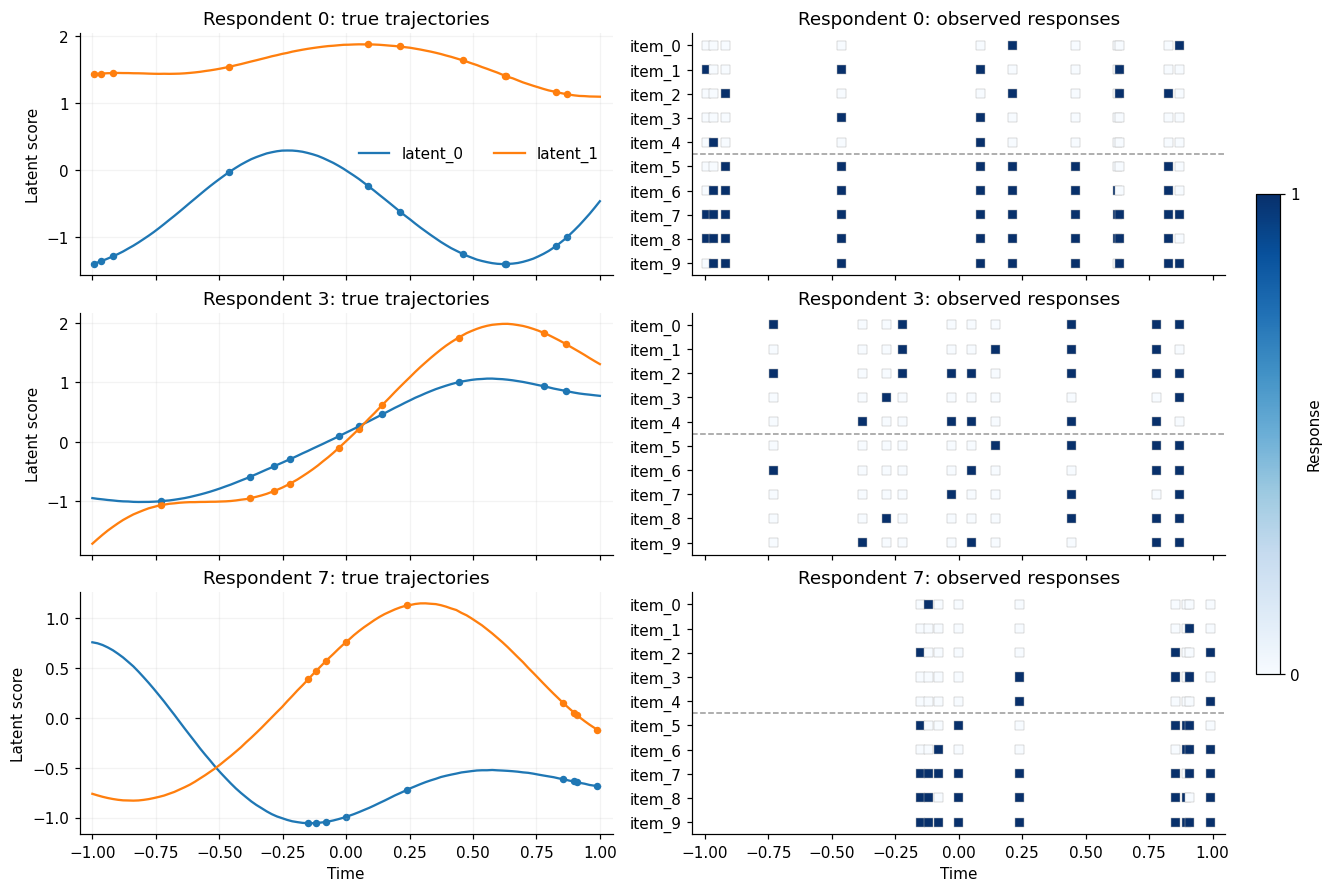

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, layout="constrained")
for row, respondent in enumerate(example_respondents):
    observed = covariates["respondent_idx"] == respondent
    times = covariates["time"][observed]
    truth_ax, response_ax = axes[row]
    for factor, latent in enumerate(latent_names):
        truth_ax.plot(dense_time, dense_trajectories[respondent, :, factor],
                      color=f"C{factor}", label=latent)
        truth_ax.scatter(times, theta_true[observed, factor], color=f"C{factor}", s=15)
    truth_ax.set(title=f"Respondent {respondent}: true trajectories", ylabel="Latent score")
    truth_ax.grid(alpha=0.15)

    raster = response_ax.scatter(
        np.repeat(times, n_items), np.tile(np.arange(n_items), len(times)),
        c=responses[observed].ravel(), cmap="Blues", vmin=0, vmax=1,
        marker="s", s=35, edgecolors="0.7", linewidths=0.3,
    )
    response_ax.axhline(4.5, color="0.6", linestyle="--", linewidth=1)
    response_ax.set(title=f"Respondent {respondent}: observed responses",
                    yticks=np.arange(n_items), yticklabels=item_names,
                    ylim=(n_items - 0.5, -0.5), xlim=(-1.05, 1.05))

axes[0, 0].legend(frameon=False, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("Time")
fig.colorbar(raster, ax=axes[:, 1], ticks=[0, 1], label="Response", shrink=0.6)
plt.show()

## 2. Give each respondent a GP

`ExactGP` takes a kernel factory: a function that builds a `tinygp` kernel from the parameters supplied by `Param`. Here we estimate one length scale shared across respondents and factors. A longer length scale favors slower changes over time. `group_by="respondent_idx"` gives each person an independent trajectory for each latent trait.

The kernel has variance fixed at one to anchor the latent scale; `Confirmatory(Q, positive=Q)` fixes the loading pattern and direction. Supplying `latent_fn` replaces the default static scores. We explicitly leave out an additional row-level residual, so the latent score is just the smooth GP.

In [5]:
trajectory = ExactGP(
    name="gp",
    predictors="time",
    group_by="respondent_idx",
    kernel=lambda params: kernels.ExpSquared(scale=params["length_scale"]),
    params={"length_scale": Param(dist.LogNormal(0, 0.5))},
)

model = dynamirt(
    model_type="2PL",
    n_latent=n_latent,
    loadings=Confirmatory(Q, positive=Q),
    latent_fn=[trajectory],
    include_residuals=False,
)

## 3. Fit with SVI

`fit_svi` optimizes an approximate posterior; its default `AutoNormal` guide uses independent normal distributions in the unconstrained parameter space. `num_steps` controls optimization, while `to_idata(num_samples=...)` controls how many draws we use afterwards for summaries and plots. Drawing more samples does not improve the fitted approximation.

Unlike MCMC, these draws do not have chain-based R-hat diagnostics. We inspect the optimization loss instead. A flattening loss is useful evidence that optimization is settling, but it does not establish that the approximation is accurate; mean-field SVI can underestimate uncertainty.

In [6]:
result = fit_svi(
    model, responses, covariates,
    num_steps=10000,
    rng_key=jax.random.PRNGKey(1),
    run_kwargs={"progress_bar": False},
)
idata = result.to_idata(
    num_samples=500,
    coords={"item": item_names, "latent": latent_names},
)
post = idata["posterior"].to_dataset()

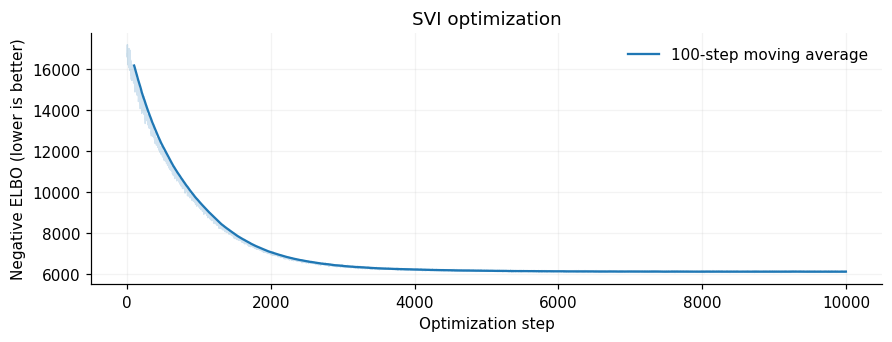

In [7]:
losses = np.asarray(result.inference.result.losses)
window = 100
smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(np.arange(1, len(losses) + 1), losses, color="C0", alpha=0.2, linewidth=0.7)
ax.plot(np.arange(window, len(losses) + 1), smoothed, color="C0",
        label=f"{window}-step moving average")
ax.set(xlabel="Optimization step", ylabel="Negative ELBO (lower is better)",
       title="SVI optimization")
ax.legend(frameon=False)
ax.grid(alpha=0.15)
plt.show()

## 4. Inspect the measurement model

The same plotting functions work with SVI draws. The heatmap shows median loadings and 95% HDIs; the item curves show the probability of a positive response as one trait varies and the other is held at zero. These are response curves over **latent scores**, not over time.

Passing `posterior=post` reuses the labeled draws. Each curve panel selects only items assigned to that factor by `Q`, and the `ax` arguments combine all three panels in one figure.

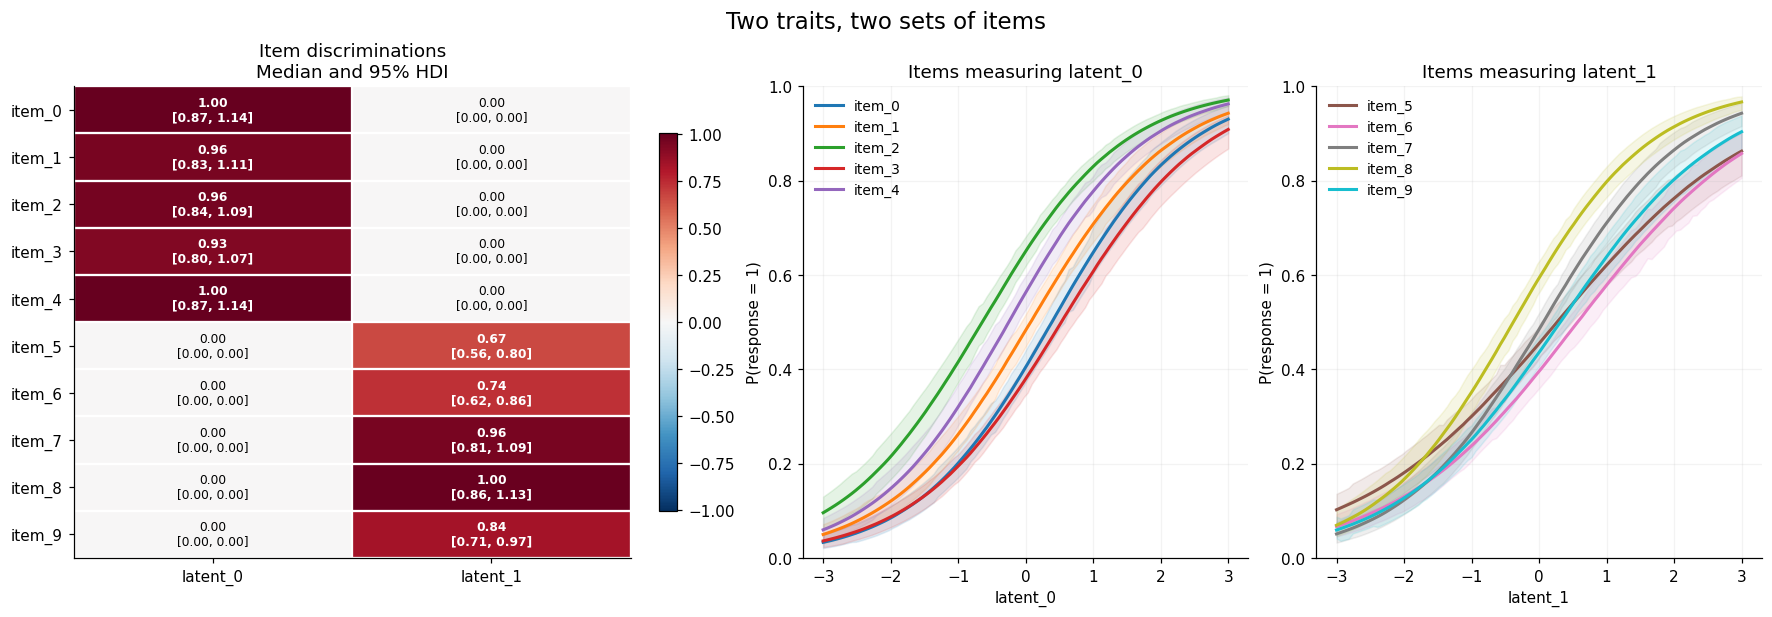

In [8]:
fig, axes = plt.subplots(
    1, 3, figsize=(16, 5.5), layout="constrained",
    gridspec_kw={"width_ratios": [1.25, 1, 1]},
)
plot_loadings(idata, ax=axes[0], text_kwargs={"fontsize": 8})
axes[0].set_title("Item discriminations\nMedian and 95% HDI")

colors = plt.get_cmap("tab10").colors
for factor, (latent, ax) in enumerate(zip(latent_names, axes[1:])):
    curves = item_curves(result, posterior=post, latent=[latent])
    for item in np.flatnonzero(Q[:, factor]):
        plot_item_curves(
            curves, item=item_names[item], category=1, ax=ax,
            line_kwargs={"color": colors[item], "label": item_names[item], "linewidth": 2},
            fill_kwargs={"alpha": 0.12},
        )
    ax.set(title=f"Items measuring {latent}", xlabel=latent,
           ylabel="P(response = 1)", ylim=(0, 1))
    ax.grid(alpha=0.15)
    ax.legend(frameon=False, fontsize=9, loc="upper left")

plt.show()

## 5. Look at fitted trajectories at the observed times

`to_idata` attaches the time and respondent covariates to the observation axis. `plot_trajectories` uses `coords` to select one respondent and `time` to sort their visits. The lines below connect posterior medians at the **observed times**, with pointwise 95% HDIs from the SVI approximation. The next step evaluates the GP between those visits.

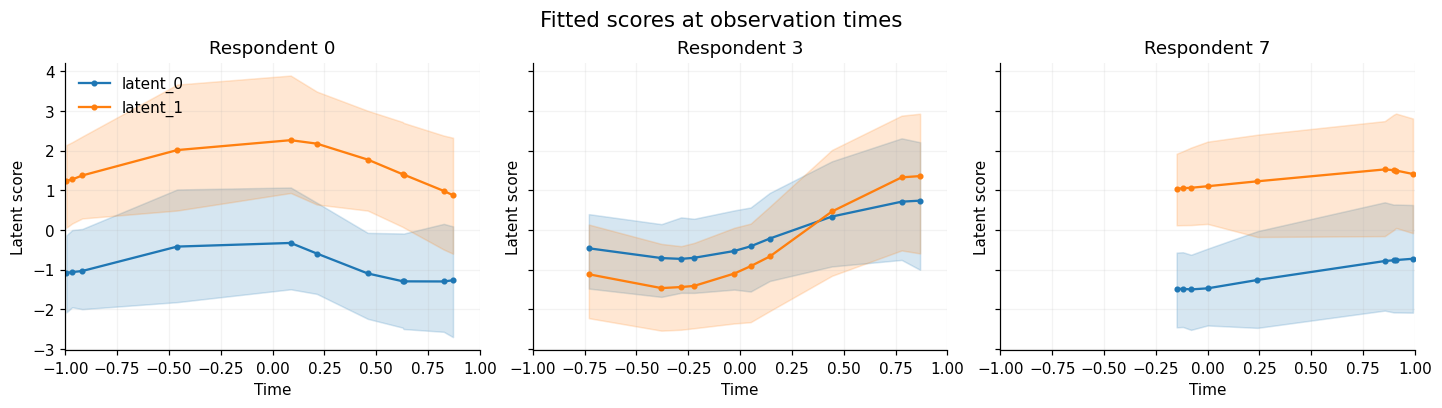

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True, layout="constrained")
for respondent, ax in zip(example_respondents, axes):
    plot_trajectories(
        idata, time="time", coords={"respondent_idx": respondent}, ax=ax,
        fill_kwargs={"alpha": 0.18},
    )
    ax.set(title=f"Respondent {respondent}", xlabel="Time", ylabel="Latent score",
           xlim=(-1, 1))
    ax.grid(alpha=0.15)
axes[0].legend(frameon=False)
fig.suptitle("Fitted scores at observation times", fontsize=14)
plt.show()

## 6. Predict on a dense time grid

We first draw model parameters from the fitted guide, then pass them to NumPyro's `Predictive`. Supplying `train_covariates` and `train_obs` activates `ExactGP`'s conditional prediction: each dense trajectory is sampled given a fitted trajectory at the training times. The simulated truth is used only for comparison, never for fitting or prediction.

Keep **all training respondent IDs** in the prediction covariates, in the same group order: the current GP implementation factorizes training and prediction groups separately. We predict for everyone and display the same three examples. This reconstructs trajectories for existing respondents, not unseen people.

In [10]:
covariates_dense = {
    "time": np.tile(dense_time, n_respondents),
    "respondent_idx": np.repeat(np.arange(n_respondents), n_dense),
}

state = result.inference
guide_draws = state.svi.guide.sample_posterior(
    jax.random.PRNGKey(2), state.result.params, sample_shape=(200,),
)
predictive = Predictive(
    model, posterior_samples=guide_draws, return_sites=["theta"],
)
dense_predictions = predictive(
    jax.random.PRNGKey(3),
    responses=None,
    covariates=covariates_dense,
    n_obs=len(covariates_dense["time"]),
    n_var=n_items,
    train_covariates=result.covariates,
    train_obs=n_obs,
)

`return_sites=["theta"]` keeps only the latent trajectories, and `Predictive` recomputes derived values on the new grid by default. We use 200 draws to limit prediction cost. The intervals reflect uncertainty in fitted parameters and the conditional GP between observations, subject to the SVI approximation.

Wrap these draws in a labeled dataset so we can reuse `plot_trajectories`. The dashed lines are the true dense paths; the small ticks mark observation times. Uncertainty can widen in gaps and beyond a person's first or last visit. These are pointwise intervals, not simultaneous bands for an entire path.

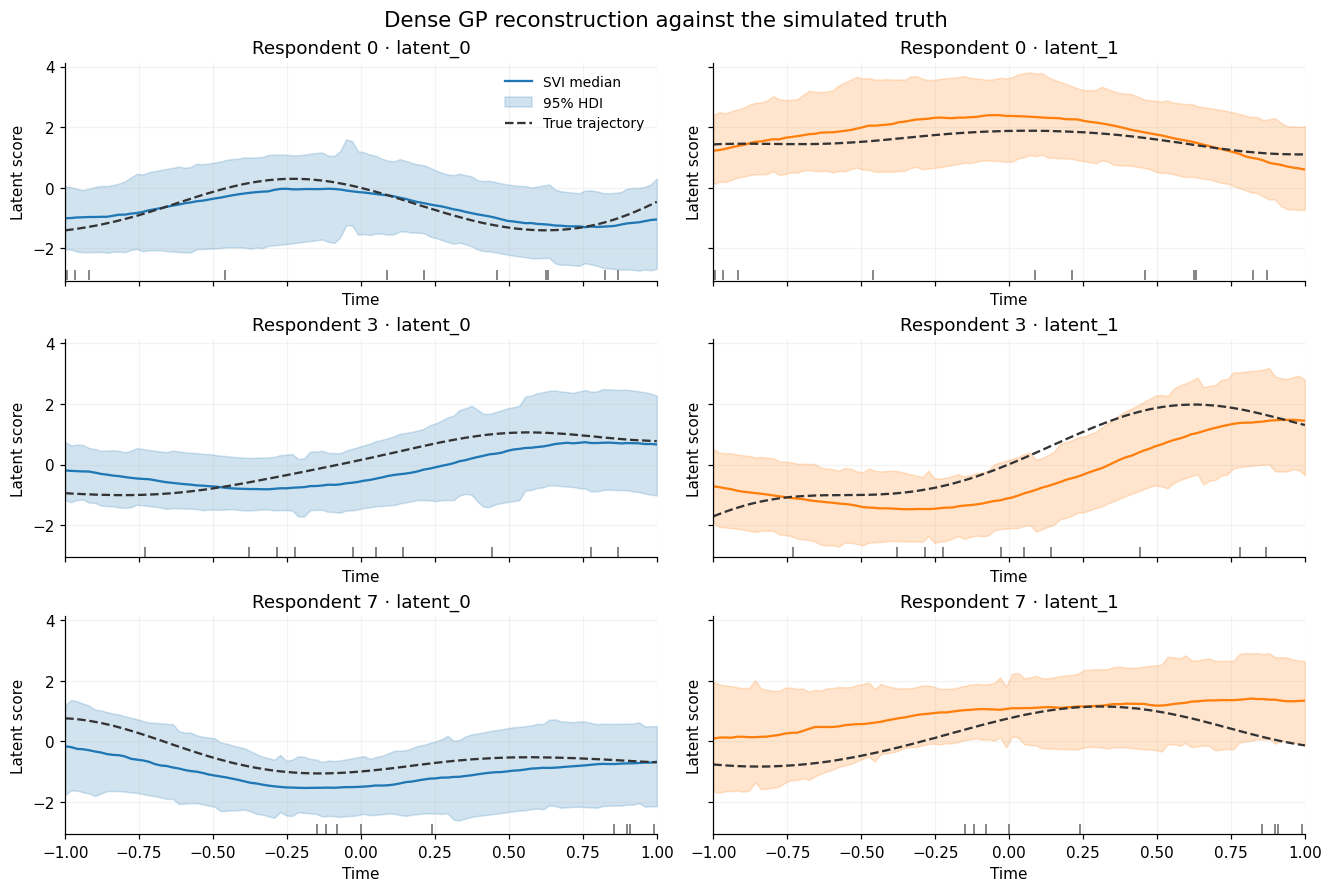

In [11]:
dense_posterior = xr.Dataset(
    {"theta": (("sample", "obs", "latent"), np.asarray(dense_predictions["theta"]))},
    coords={
        "sample": np.arange(dense_predictions["theta"].shape[0]),
        "obs": np.arange(len(covariates_dense["time"])),
        "latent": latent_names,
        "time": ("obs", covariates_dense["time"]),
        "respondent_idx": ("obs", covariates_dense["respondent_idx"]),
    },
)
dense_idata = xr.DataTree.from_dict({"posterior": dense_posterior})

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True,
                         layout="constrained")
for row, respondent in enumerate(example_respondents):
    observed = covariates["respondent_idx"] == respondent
    for factor, latent in enumerate(latent_names):
        ax = axes[row, factor]
        plot_trajectories(
            dense_idata, time="time", coords={"respondent_idx": respondent},
            latent=latent, ax=ax,
            line_kwargs={"marker": "", "color": f"C{factor}", "label": "SVI median"},
            fill_kwargs={"alpha": 0.2, "label": "95% HDI"},
        )
        ax.plot(dense_time, dense_trajectories[respondent, :, factor],
                color="0.2", linestyle="--", linewidth=1.5, label="True trajectory")
        ax.plot(covariates["time"][observed], np.full(observed.sum(), 0.025),
                "|", color="0.4", markersize=6, transform=ax.get_xaxis_transform())
        ax.set(title=f"Respondent {respondent} · {latent}",
               xlabel="Time", ylabel="Latent score", xlim=(-1, 1))
        ax.grid(alpha=0.15)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Dense GP reconstruction against the simulated truth", fontsize=14)
plt.show()

## Try your own time series

Replace the response array and aligned respondent/time covariates, then choose a Q matrix. Scale time deliberately: the length-scale prior is expressed in those units. Before drawing substantive conclusions, check sensitivity to optimization settings and the variational approximation, for example with an MCMC fit to a smaller dataset.

API references for the future Sphinx version (plain Jupyter may display the role syntax): {py:class}`dynamirt.gllvm.terms.continuous.ExactGP`, {py:func}`dynamirt.fit.fit_svi`, and {py:func}`dynamirt.diagnostics.plot_trajectories`. NumPyro's [Predictive documentation](https://num.pyro.ai/en/stable/utilities.html#predictive) describes the prediction wrapper; the kernel comes from [tinygp](https://tinygp.readthedocs.io/en/latest/api/kernels.html).